# Logistic Perceptron

In diesem Kapitel behandeln wir das Logistische Perzeptron und dessen Herleitung. Dieses Kapitel ist fundamental zur Verständnisbildung für Deep Learning in zweierlei Hinsicht:

1. Es findet nun eine transition von regelbasierten Lernverfahren, wie der Fehlerzähler aus dem Kapitel Perzeptron zu Optimierungsbasierten Modellen statt. 

2. Es wird aufgezeigt das die Modellausgabe und das Optimierungsziel aufeinander abgestimmt werden müssen.  

3. Interpretation der Ausgabe

Objectives: 

Das logistische Perzeptron verstehen

Zusammenhang zwischen Liklihood und BCE beim logistischen Perzeptron aus der Herleitung binomialverteilten 
generalisierten linearen Modellen

Sigmoid für Binary Classification, Softmax für ...

Vorwissen:
- Perzeptron
- Gradient Descent


As discussed in the previous chapter, the Rosenblatt perceptron produces strictly binary outputs and is not trained by minimising a continuous objective function.
The logistic perceptron addresses both limitations by replacing the hard threshold with a smooth activation function. To motivate this change, we first consider a small synthetic binary classification dataset.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import beginner.perceptron.perceptron as perceptron

In [2]:
rng = np.random.default_rng(53)


## Review: Activation Function

Since the model only differs in the use of the sigmoid function as the output activation, we will briefly review it first.


**Sigmoid:**
$$ f(x)=\frac{1}{1+e^{-x}} $$

You can see at a glance that:
- The value range is in **(0,1)**
- Monotonically increasing
- For large **|x|**, the value approaches **0** or **1**
- Continuously differentiable

The output of the sigmoid function can be given semantics. For binary classification, this means:
- $\sigma(z) < 0.5$ → Class **0**
- $\sigma(z) >= 0.5$ → Class **1**


**Step function:**

You can see at a glance:
- Values can only be **0** or **1**
- **x = 0** is not defined
- even if differentiable, slope = 0 -> no usable gradient -> no information content


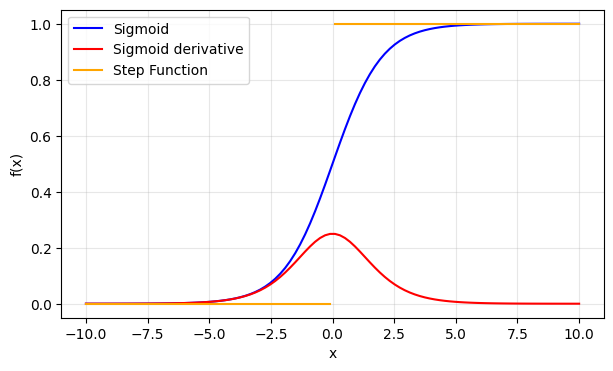

In [3]:
x = np.linspace(-10, 10, 100)
fig2, ax2 = plt.subplots(figsize=(7, 4))

ax2.plot(x, perceptron.sigmoid(x), c="blue", label="Sigmoid")
ax2.plot(x, perceptron.sigmoid_derivative(x), c="red", label="Sigmoid derivative")
ax2.plot(x[x < 0], perceptron.step_function(x[x < 0]), c="orange", label="Step Function")
ax2.plot(x[x >= 0], perceptron.step_function(x[x >= 0]), c="orange")

ax2.grid(alpha=0.3)
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")
ax2.legend();

## Data Generation

First, we generate a linearly separable synthetic dataset with a fictional decision boundary. Data points below this boundary are assigned to class 0, while data points above the boundary are assigned to class 1.

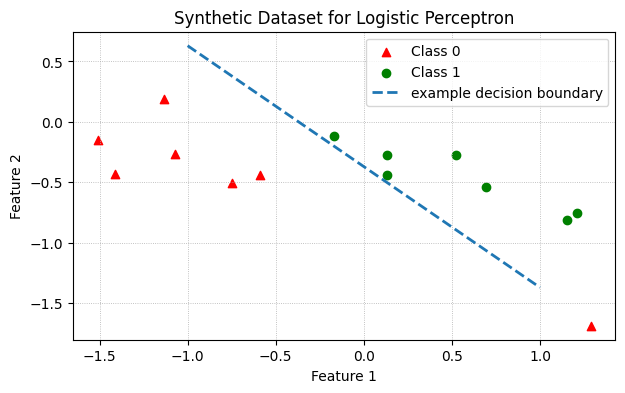

In [4]:
X, y = make_classification(
    n_samples=14,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.5,
    flip_y=0.0,
    random_state=53
)
y_train = np.asarray(y).reshape(-1, 1)

def visualize_data(X: np.ndarray, y:np.ndarray, title:str):
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(X[y==0,0], X[y==0,1], color="red", marker="^", label="Class 0")
    ax.scatter(X[y==1,0], X[y==1,1], color="green", marker="o", label="Class 1")    
    ax.legend()
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.grid(ls=":", linewidth=0.6)
    return fig, ax

fig1,ax1 = visualize_data(X,y,"Synthetic Dataset for Logistic Perceptron")
perceptron.ex_boundary_helper(ax1,-0.37)

# Training

We now train the logistic perceptron using the error-counting approach from the Perceptron chapter and inspect the model output for each data point.

**Dev Diary:**  
Although our training method expects `y` to have shape `(n_samples, 1)`, I accidentally passed it with shape `(14,)`. I was aware of both shapes, but still overlooked it. A small mistake, but an annoying bug hunt.


Solution in Epoch 48


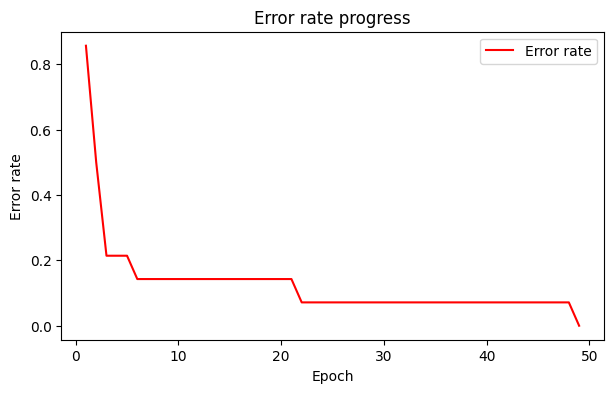

In [5]:
model = perceptron.Perceptron(X.shape[1], perceptron.sigmoid)
error_history,_ = model.train(X, y_train, lr=0.1, error_prints=False, epochs=100)
fig2, ax2 = perceptron.visualize_training(error_history)



## Helper Functions

To visualize decision boundaries throughout the rest of the notebook, we will now define two helper functions.

In [6]:
def create_2d_grid(X: np.ndarray, steps: int = 100, padding: float = 0.2):
    """
    Creates a 2D feature grid based on the range of the input data.

    Args:
        X (np.ndarray):
            Feature matrix of shape (n_samples, 2).
        steps (int):
            Number of grid points per axis.
        padding (float):
            Additional margin added around the data range.

    Returns:
        x1_grid, x2_grid:
            Meshgrid arrays of shape (steps, steps).
        X_feature_grid:
            Flattened feature grid of shape (steps * steps, 2).
    """
    assert X.shape[1] == 2, "This function only supports 2D input data."

    x1_min, x1_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x2_min, x2_max = X[:, 1].min() - padding, X[:, 1].max() + padding

    x1 = np.linspace(x1_min, x1_max, steps)
    x2 = np.linspace(x2_min, x2_max, steps)

    x1_grid, x2_grid = np.meshgrid(x1, x2)
    X_feature_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]

    return x1_grid, x2_grid, X_feature_grid

def visualize_decision_boundary(
    model: "perceptron.Perceptron",
    X: np.ndarray,
    y: np.ndarray,
    description: str,
    annotation: bool = True,
    max_annotations: int | None = None,
    padding: float = 0.2,
    steps: int = 100
):
    """
    Visualizes the learned decision boundary of a perceptron.
    Args:
        model:
            Trained model
        X (np.ndarray):
            Feature matrix of shape (n_samples, 2).
        y (np.ndarray):
            labels corresponding to X
        description (str):
            Title
        padding (float):
            Additional margin added around the data range.
        annotation (bool):
            If True, displays the model output at each data point.
        max_annotations (int): 
            set the number of max annotations in figure
        steps (int):
            Number of grid points per axis
        

    Returns:
        fig, ax:
            Matplotlib figure and axes objects.
    """
    x1_grid, x2_grid, X_feature_grid = create_2d_grid(
        X=X,
        steps=steps,
        padding=padding
    )
    y_vis = model.forward(X_feature_grid).reshape(steps,-1)
    fig, ax = visualize_data(X,y,description)
    cf = ax.contourf(x1_grid, x2_grid, y_vis, levels=10, cmap='coolwarm', alpha=0.6, zorder=0)
    prediction = model.forward(X).reshape(-1)
    if annotation:
        rng = np.random.default_rng(53)
        if max_annotations is None:
            max_annotations = len(y)
        n_annotations = min(max_annotations, len(X))
        annotation_idx = rng.choice(len(X), size=n_annotations, replace=False)
        for idx in annotation_idx:
            xi = X[idx]
            y_hat = prediction[idx]
            ax.annotate(
                f"{y_hat:.2f}",
                xy=(xi[0], xi[1]),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8,
            )
    fig.colorbar(cf, label="Prediction")
    return fig, ax


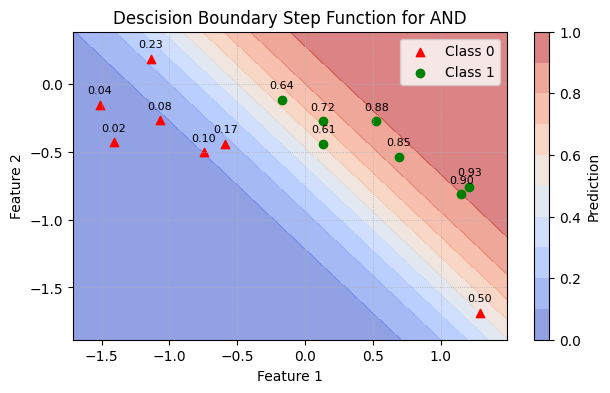

In [7]:
fig2, ax2 = visualize_decision_boundary(model, X, y, "Descision Boundary Step Function for AND")

## Evaluating Sigmoid with Error Counting

At this stage, the output value can be interpreted as a geometrically meaningful decision score relative to the decision boundary. High values correspond to points on the side of class 1, while low values correspond to points on the side of class 0. The closer a data point lies to the decision boundary, the closer the output is to 0.5.

## Part 1: Probabilistically Justified Predictions

In the next part, we examine how moving from rule-based learning to an optimization objective allows us to give the model output a probabilistic interpretation.

This point is important because the meaning of a model output does not come from its numerical value alone. A value between 0 and 1 is not automatically a probability. It becomes meaningful only when the output function and the training objective support this interpretation.

The goal is therefore to move from a simple decision score to a probabilistically justified prediction.

## Synthetic Dataset with Overlapping Classes

For the following sections, we will use a synthetic dataset with two features and binary target values that is not perfectly linearly separable.

As we already saw in the Perceptron chapter, this exposes a limitation of purely rule-based learning procedures such as error counting. Error counting only distinguishes between correct and incorrect predictions. For example, if the true label is $y=1$, then predictions of $p=0.51$ and $p=0.99$ would both be counted as correct after applying a threshold.

However, these two predictions are not equally informative. A prediction of $0.99$ assigns much more confidence to the observed label than a prediction of $0.51$. Our training objective should be able to take this difference into account.

We use this synthetic dataset as an observed sample. The model only sees these data points and has to learn a relationship between the features and the binary labels from this sample.

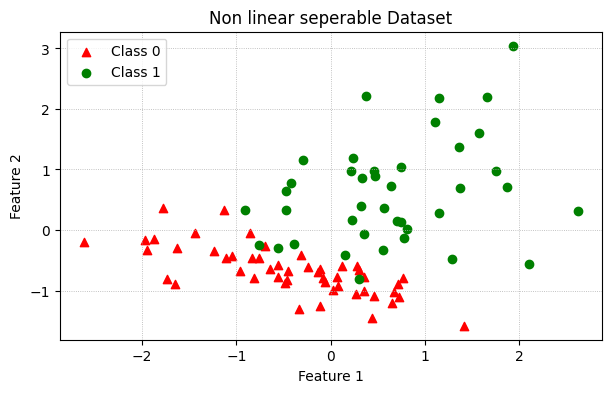

In [8]:
X, y = make_classification(
    n_samples=90,
    n_features=2,
    n_redundant=0,
    weights=[0.55, 0.45],
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=0.6,
    flip_y=0.0,
    random_state=51
)
fig3,ax3 = visualize_data(X,y,"Non linear seperable Dataset")



A quick exploration shows that there is a class imbalance. Class 1 occurs less frequently in the dataset.

In [9]:
unique, counts = np.unique(y, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique,
    "Absolute frequency": counts,
    "Relative frequency": (counts / len(y)).round(2)
})

class_distribution

,Class,Absolute frequency,Relative frequency
0,0,50,0.56
1,1,40,0.44


In [10]:
p_empirical = np.mean(y)

print(f"Empirical relative frequency of class 1: {p_empirical:.3f}")
print(f"Empirical relative frequency of class 0: {1 - p_empirical:.3f}")

Empirical relative frequency of class 1: 0.444
Empirical relative frequency of class 0: 0.556


## Binary Target Variables as Bernoulli Random Variables

A data point has a binary label:

**1** or **0**, **success** or **failure**

A Bernoulli random variable $Y$ is described by exactly one parameter $p$. This parameter represents the probability that the event $Y=1$ occurs. Accordingly, the probability of the opposite event $Y=0$ is $1-p$:

$$
P(Y=1)=p, \qquad P(Y=0)=1-p
$$

This changes how we view the classification problem. So far, we could think of the label in a purely deterministic way: 

A data point belongs either to one class or to the other. From the Bernoulli perspective, we now view the label as the **realization of a binary random experiment**.

An important distinction is the difference between the **observed label** and the **underlying probability**:

- The observed label is the actually realized value, so $y_i \in \{0,1\}$.
- The Bernoulli parameter describes the probability with which the event $Y=1$ occurs.

For a classification model with input features, this probability is not the same for all data points. Instead of a single global parameter $p$, we are interested in an individual conditional probability for each sample $x_i$:

$$
p_i = P(Y=1 \mid X=x_i)
$$

In practice, we do not know this probability directly. We only observe the inputs $x_i$ and their corresponding labels $y_i$. The goal of the model is therefore to estimate this unknown probability from the input features.

At this point, the difference to the relative frequency in the dataset becomes clear. The empirical frequency of class $1$ only describes how often class $1$ occurs in the observed dataset as a whole. It is a global property of the sample. The logistic perceptron, however, aims to model an individual probability $p_i$ for each data point.

## From Model Output to Class Probability

We now extend the previous model assumption with:

$$
p_i = \sigma(z_i)=\sigma(w^\top x_i+b)
$$

Under the Bernoulli model assumption, we interpret this output as an estimate of the conditional probability

$$
p_i = P(Y=1 \mid X=x_i)
$$

This does not replace the geometric interpretation of the decision score. Instead, it adds a **probabilistic meaning** to it.



## BCE as an Optimization Objective

A suitable optimization objective should evaluate how much probability the model assigns to the actually observed label.

For a single data point, the Binary Cross-Entropy is defined as:

$$
\mathrm{BCE}(y_i,p_i)
=
-\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

For $y_i=1$, only the following term remains:

$$
\mathrm{BCE}(1,p_i)=-\log(p_i)
$$

For $y_i=0$, only the following term remains:

$$
\mathrm{BCE}(0,p_i)=-\log(1-p_i)
$$

The two cases show that the loss depends on the probability assigned to the actually observed label. The information-theoretic interpretation of “Cross-Entropy” will be discussed in a separate chapter.

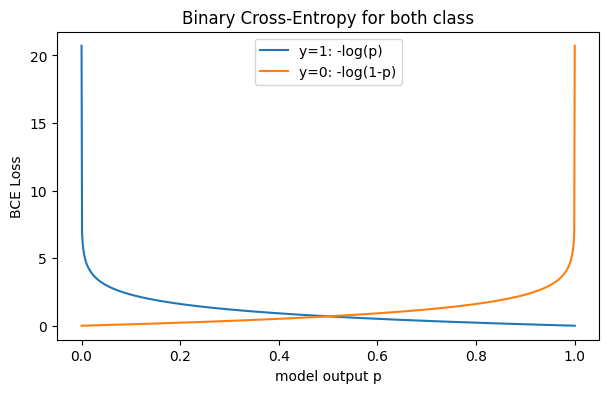

In [11]:
stability_term = 1e-9
p_values = np.linspace(stability_term, 1 - stability_term, 1000)

bce_y1 = -np.log(p_values)
bce_y0 = -np.log(1 - p_values)

fig4, ax4 = plt.subplots(figsize=(7, 4))

ax4.plot(p_values, bce_y1, label="y=1: -log(p)")
ax4.plot(p_values, bce_y0, label="y=0: -log(1-p)")

ax4.set_xlabel("model output p")
ax4.set_ylabel("BCE Loss")
ax4.set_title("Binary Cross-Entropy for both class")
ax4.legend()

## Probability of the Observed Label and the Role of the Logarithm

Binary Cross-Entropy becomes easier to interpret when we explicitly focus on the probability of the actually observed label.

The sigmoid output $p_i$ first describes the model's predicted probability for class $1$:

$$
p_i = P(Y=1 \mid X=x_i)
$$

For evaluating a concrete data point, however, the relevant probability depends on the observed label. 
If $y_i=1$, the relevant probability is $p_i$. If $y_i=0$, the relevant probability is $1-p_i$.

Both cases can be written compactly as

$$
q_i = y_i p_i + (1-y_i)(1-p_i)
$$

Here, $q_i$ denotes the probability that the model assigns to the actually observed label. Since $y_i$ can only take the values $0$ or $1$, it acts like a switch:

- For $y_i=1$, we get $q_i=p_i$.
- For $y_i=0$, we get $q_i=1-p_i$.

Using this notation, the Binary Cross-Entropy for a single data point can be written as

$$
\mathrm{BCE}(y_i,p_i)=-\log(q_i)
$$

BCE is small when the model assigns a high probability to the observed label, and large when this probability is small.

The negative logarithm amplifies this effect. If $q_i$ is close to $1$, then approximately

$$
-\log(q_i) \approx 0
$$

The model has assigned a high probability to the observed label, so the loss is small.

If $q_i$ is close to $0$, then

$$
-\log(q_i)
$$

becomes very large. In that case, the model assigned only a very small probability to the actually observed label.

Binary Cross-Entropy therefore strongly penalizes predictions where the model assigns very little probability to the observed label. This is why it is well suited as an optimization objective for probabilistic classification.

In [12]:
examples = pd.DataFrame({
    "y": [1, 1, 1, 0, 0, 0, 1,],
    "p": [0.99, 0.50, 0.01, 0.01, 0.50, 0.99, 0.001]
})

examples["q"] = (
    examples["y"] * examples["p"] 
    + (1 - examples["y"]) * (1 - examples["p"])
)

examples["BCE"] = -np.log(examples["q"])

examples.round(4)

,y,p,q,BCE
0,1,0.990,0.990,0.0101
1,1,0.500,0.500,0.6931
2,1,0.010,0.010,4.6052
3,0,0.010,0.990,0.0101
4,0,0.500,0.500,0.6931
5,0,0.990,0.010,4.6052
6,1,0.001,0.001,6.9078


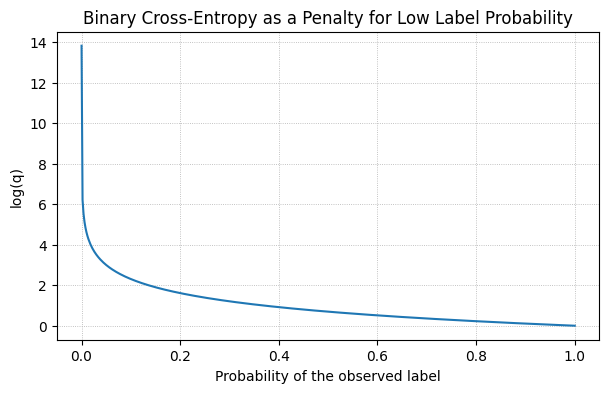

In [13]:

q_values = np.linspace(1e-6, 1, 500)
loss_values = -np.log(q_values)

fig4, ax4 = plt.subplots(figsize=(7, 4))

ax4.plot(q_values, loss_values)

ax4.set_xlabel("Probability of the observed label")
ax4.set_ylabel("log(q)")
ax4.set_title("Binary Cross-Entropy as a Penalty for Low Label Probability")
ax4.grid(ls=":", linewidth=0.6)

plt.show()

## Binary Cross-Entropy over the Entire Dataset

For a dataset with $n$ observations, Binary Cross-Entropy is typically computed as the mean of the individual loss values:

$$
\mathrm{BCE}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Taking the mean ensures that the loss does not grow directly with the number of data points.

Conceptually, the mean Binary Cross-Entropy evaluates how much probability the model assigns to the observed labels on average.

In [14]:
def binary_cross_entropy(y_true: np.ndarray, p_pred: np.ndarray) -> float:
    """
    Computes the mean Binary Cross-Entropy.

    Parameters
    ----------
    y_true : np.ndarray
        Binary labels with values 0 or 1.
    p_pred : np.ndarray
        Predicted probabilities for class 1.

    Returns
    -------
    float
        Mean Binary Cross-Entropy.
    """
    y_true = y_true.flatten()
    p_pred = p_pred.flatten()
    stability_term = 1e-9

    p_pred = np.clip(p_pred, stability_term, 1 - stability_term)

    loss = -(
        y_true * np.log(p_pred)
        + (1 - y_true) * np.log(1 - p_pred)
    )

    return np.mean(loss)

## BCE as a Function of the Model Parameters

So far, we have considered Binary Cross-Entropy as a function of the observed label $y_i$ and the predicted probability $p_i$.

In the logistic perceptron, however, this probability is produced by the model parameters $w$ and $b$:

$$
p_i = \sigma(w^\top x_i + b)
$$

Therefore, the loss does not only depend on $p_i$ directly, but also indirectly on the model parameters. If we put the model equation into the Binary Cross-Entropy, we obtain for a single data point:

$$
\mathrm{BCE}(y_i,w,b)
=
-\left[
y_i \log(\sigma(w^\top x_i+b))
+
(1-y_i)\log(1-\sigma(w^\top x_i+b))
\right]
$$

For the entire dataset, we take the mean over all data points:

$$
\mathrm{BCE}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\sigma(w^\top x_i+b))
+
(1-y_i)\log(1-\sigma(w^\top x_i+b))
\right]
$$

This turns the training of the logistic perceptron into an optimization problem:

$$
\min_{w,b} \ \mathrm{BCE}(w,b)
$$

The goal is to adjust the weights $w$ and the bias $b$ so that the mean Binary Cross-Entropy on the dataset becomes as small as possible.

This is a fundamental difference compared to a purely rule-based update. We now explicitly define a loss function and search for parameters that minimize this loss. Interested readers can find more details in the **Gradient Descent** chapter series.

## 8. Gradient for the Logistic Perceptron

This follows the same idea as in the **Gradient Descent** chapter series, but this time with Binary Cross-Entropy and an additional activation function.

Here, $p_i$ denotes the predicted probability for class $1$.

The red term $p_i-y_i$ is the error signal at the output. It arises from the combination of the BCE derivative and the sigmoid derivative.

$$
\Large
\begin{aligned}
\nabla_{w,b}\,\mathrm{BCE}
&=
\begin{bmatrix}
\dfrac{\partial\,\mathrm{BCE}}{\partial w} \\
\dfrac{\partial\,\mathrm{BCE}}{\partial b}
\end{bmatrix}
=
\frac{1}{n}
\sum_{i=1}^{n}
\begin{bmatrix}
x_i{\color{red}{(p_i-y_i)}} \\
{\color{red}{(p_i-y_i)}}
\end{bmatrix}
\\[1em]
\frac{\partial \mathrm{BCE}}{\partial w}
&=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{\frac{\partial \mathrm{BCE}_i}{\partial p_i}}}
\cdot
{\color{red}{\frac{\partial p_i}{\partial z_i}}}
\cdot
\frac{\partial z_i}{\partial w}
=
\frac{1}{n}
\sum_{i=1}^{n}
x_i{\color{red}{(p_i-y_i)}}
\\[0.8em]
\frac{\partial \mathrm{BCE}}{\partial b}
&=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{\frac{\partial \mathrm{BCE}_i}{\partial p_i}}}
\cdot
{\color{red}{\frac{\partial p_i}{\partial z_i}}}
\cdot
\frac{\partial z_i}{\partial b}
=
\frac{1}{n}
\sum_{i=1}^{n}
{\color{red}{(p_i-y_i)}}
\end{aligned}
$$

## Why Sigmoid with BCE?

In principle, any differentiable activation function with output range $(0,1)$ could be used to interpret the output as a Bernoulli parameter. 

$$
p_i = g(z_i)
$$


However, the sigmoid function is suitable because, together with Binary Cross-Entropy, it produces a very simple and interpretable derivative. For a general activation function $g$ with $p_i=g(z_i)$, we get:

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}
=
\frac{p_i-y_i}{p_i(1-p_i)}
\cdot
g'(z_i)
$$

For the sigmoid function, we have:

$$
g'(z_i)=\sigma(z_i)(1-\sigma(z_i))=p_i(1-p_i)
$$

This simplifies the output error signal to:

$$
\frac{\partial \mathrm{BCE}}{\partial z_i}=p_i-y_i
$$

This simplification is not only computationally elegant, but also semantically meaningful: the learning signal is directly the difference between the predicted probability and the observed label.

Therefore, the sigmoid function is not just an transformation into the interval $(0,1)$. It fits particularly well with the Bernoulli model assumption and Binary Cross-Entropy.

# Visualizing the BCE Derivative and the Error Signal

To better understand the interaction between Binary Cross-Entropy and the sigmoid activation, we now visualize both the derivative of BCE with regard to the predicted probability $p_i$ and the resulting error signal.

We get these two cases:

- if $y_i=0$, then $p_i-y_i=p_i$
- if $y_i=1$, then $p_i-y_i=p_i-1$

The left plot shows the derivative of Binary Cross-Entropy with regard to the predicted probability $p_i$.

The right plot shows the resulting error signal

$$
p_i-y_i
$$

which happens after taking the sigmoid derivative into account. This signal is much easier to interpret:

- For $y_i=1$, the error signal is negative as long as $p_i<1$.
- For $y_i=0$, the error signal is positive as long as $p_i>0$.
- The closer the predicted probability is to the observed label, the smaller the magnitude of the error signal.

This simple error signal is exactly what we use in the next step to compute the gradients in regard to the model parameters $w$ and $b$.

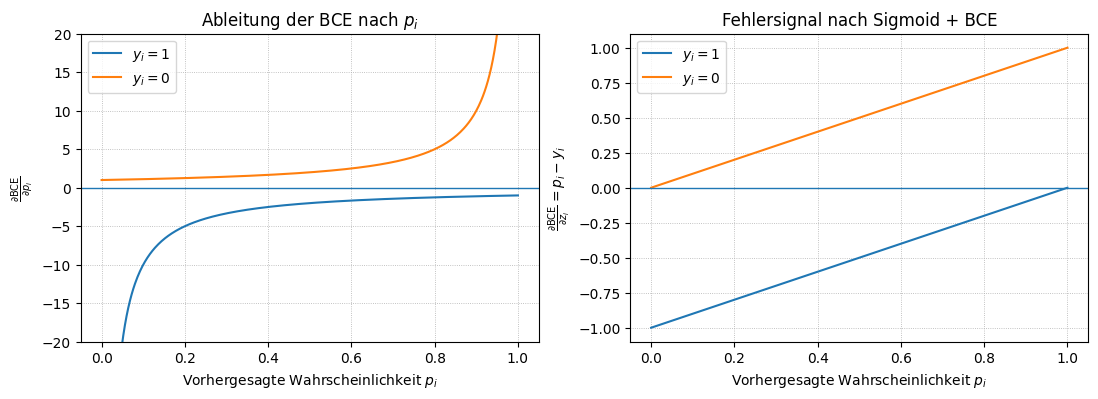

In [15]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-6
p_values = np.linspace(eps, 1 - eps, 500)

# Ableitung der BCE nach p
d_bce_dp_y1 = -1 / p_values
d_bce_dp_y0 = 1 / (1 - p_values)

# Fehlersignal nach Berücksichtigung der Sigmoid-Ableitung:
# dBCE/dz = p - y
signal_y1 = p_values - 1
signal_y0 = p_values - 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linker Plot: Ableitung der BCE nach p
axes[0].plot(p_values, d_bce_dp_y1, label=r"$y_i=1$")
axes[0].plot(p_values, d_bce_dp_y0, label=r"$y_i=0$")
axes[0].axhline(0, linewidth=1)
axes[0].set_xlabel(r"Vorhergesagte Wahrscheinlichkeit $p_i$")
axes[0].set_ylabel(r"$\frac{\partial \mathrm{BCE}}{\partial p_i}$")
axes[0].set_title("Ableitung der BCE nach $p_i$")
axes[0].set_ylim(-20, 20)
axes[0].legend()
axes[0].grid(ls=":", linewidth=0.6)

# Rechter Plot: Fehlersignal p - y
axes[1].plot(p_values, signal_y1, label=r"$y_i=1$")
axes[1].plot(p_values, signal_y0, label=r"$y_i=0$")
axes[1].axhline(0, linewidth=1)
axes[1].set_xlabel(r"Vorhergesagte Wahrscheinlichkeit $p_i$")
axes[1].set_ylabel(r"$\frac{\partial \mathrm{BCE}}{\partial z_i}=p_i-y_i$")
axes[1].set_title("Fehlersignal nach Sigmoid + BCE")
axes[1].legend()
axes[1].grid(ls=":", linewidth=0.6)

## Interpretation of the Visualization

The visualization highlights an important difference between the BCE loss itself and the error signal that is passed back through the output.

The BCE loss can become very large when the model assigns only a very small probability to the observed label. The derivative of BCE with respect to the predicted probability $p_i$ can also become very large in these regions.

After combining BCE with the sigmoid activation, however, the local error signal at the output logit becomes much simpler. It is no longer an unbounded expression in terms of $p_i$, but the direct difference between the predicted probability and the observed label.

So the BCE loss itself is not bounded. What becomes simple and bounded is the local error signal at the output logit.

# Training
Now we can create the function for the training. For the time being, we will continue to use the full-batch gradient descent algorithm, which we are already familiar with from the chapter on **Gradient Descent**.





In [16]:
print(f"Shape X : {X.shape}, Shape y: {y.shape}")
def train(model: perceptron.Perceptron, X: np.ndarray, y: np.ndarray, lr=0.01, epochs=10000):
    """
    Trains the logistic Perceptron using full batch gd for BCE+Sigmoid

    Args:
        model Perzeptron object
        X (np.ndarray): Input data of shape (n_samples, n_features).
        y (np.ndarray): Target labels of shape (n_samples, 1) 
        lr (float): Learning rate
        epochs (int): Maximum number of training epochs.

    Returns: 
        list[float]: Mean Binary Cross-Entropy after each epoch. Initial loss is not included.
    """
    y = y.reshape(-1,1)
    loss_history = []
    for epoch in range(epochs):
        prediction = model.forward(X)
        assert prediction.shape == y.shape, "shape missmatch"
        error_signal = (prediction - y)
        model.weight = model.weight - lr * ((X.T @ error_signal)/X.shape[0])
        model.bias = model.bias - lr * np.mean(error_signal)
        prediction = model.forward(X)
        mean_loss = binary_cross_entropy(y, prediction)
        loss_history.append(mean_loss)
    return loss_history

Shape X : (90, 2), Shape y: (90,)


The model is initialised and trained as usual, and the BCE loss is plotted. For illustrative purposes and for the later part of the notebook, I have divided the training into two phases here. First, training is carried out over 10,000 epochs, followed by a further 190,000 epochs using the parameters already learned.

Start Loss: 0.88
Final Loss: 0.15


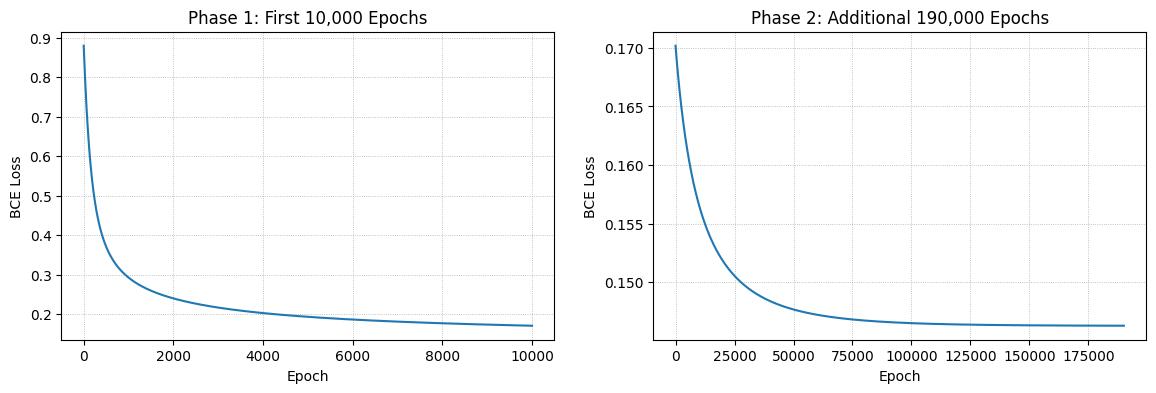

In [17]:
model = perceptron.Perceptron(X.shape[1], perceptron.sigmoid)
loss_history_1 = train(model, X, y)
loss_history_2 = train(model, X, y,epochs=190000)

fig6, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

perceptron.visualize_loss(
    loss_history_1,
    y_label="BCE Loss",
    x_label="Epoch",
    ax=ax1,
    title="Phase 1: First 10,000 Epochs"
)

perceptron.visualize_loss(
    loss_history_2,
    y_label="BCE Loss",
    x_label="Epoch",
    ax=ax2,
    title="Phase 2: Additional 190,000 Epochs"
)
print(f"Start Loss: {round(loss_history_1[0], 2)}")
print(f"Final Loss: {round(loss_history_2[-1], 2)}")

## Short Interpretation

The training shows that the mean Binary Cross-Entropy decreases continuously over the epochs. During training, the loss approaches a final value of approximately $0.15$. The parameters were adjusted so that the observed labels become more plausible under the predicted probabilities.

**Conclusion:** The model fits the training data better as training progresses.

However, we should not conclude from the initial BCE alone that the model classifies worse than random guessing. BCE evaluates predicted probabilities, not accuracy. Accuracy measures the proportion of correctly classified predictions after applying a decision threshold.

As a reference, we can consider a constant probabilistic baseline model. This model predicts the empirical frequency of class $0$ for every data point. For our sample, this is approximately $p=0.56$. The corresponding BCE is

$$
-\left[0.56\log(0.56)+0.44\log(0.44)\right]\approx 0.686.
$$

The initial training loss of approximately $0.88$ is above this baseline. This means that the randomly initialized model initially assigns, on average, less suitable probabilities to the observed labels than this constant reference model. Individual data points can contribute differently to the mean loss.

Since we only consider the training loss here, this does not yet tell us how well the model generalizes to unseen data.

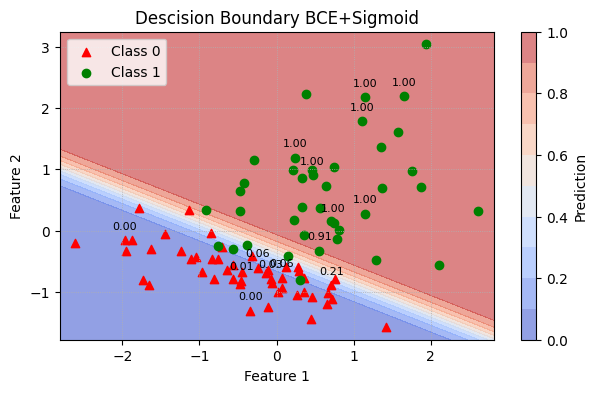

In [18]:
fig7, ax7 = visualize_decision_boundary(model, X, y, "Descision Boundary BCE+Sigmoid", True, 15)

## Probability Surface and Decision Boundary

The colored regions show the probability surface learned by the model.

Red regions correspond to high predicted probabilities for class $1$, while blue regions correspond to low predicted probabilities for class $1$. The lighter transition region appears where the model distinguishes less clearly between the two classes.

Using the standard threshold of $0.5$, the decision boundary is located where

$$
p(x)=0.5.
$$

Since the sigmoid function satisfies

$$
\sigma(0)=0.5,
$$

this boundary corresponds exactly to all points for which

$$
w^\top x+b=0.
$$

Therefore, the geometric interpretation is preserved. The linear score

$$
z=w^\top x+b
$$

still describes the position of a point relative to the decision boundary. Points with $z>0$ lie on the side of class $1$, while points with $z<0$ lie on the side of class $0$. The farther a point is from the decision boundary, the larger the magnitude of $z$.

The sigmoid function adds a probabilistic interpretation to this geometric view. It transforms the linear score into a probability between $0$ and $1$:

$$
p(x)=\sigma(z).
$$

As a result, points far on the side of class $1$ receive probabilities close to $1$, points far on the side of class $0$ receive probabilities close to $0$, and points close to the decision boundary receive probabilities close to $0.5$.

The probability surface therefore contains more information than the hard decision boundary alone. The boundary only shows where the predicted class would change under a chosen threshold, while the probability surface also shows how strongly the model leans toward class $1$ or class $0$.

## Converting Probabilities into Classes

The logistic perceptron does not directly output a hard class label. Instead, it outputs a predicted probability for class $1$:

$$
p_i = P(Y=1 \mid X=x_i)
$$

To turn this probability into a concrete class prediction, we use a decision threshold. The standard choice is a threshold of $0.5$:

$$
\hat y_i =
\begin{cases}
1, & \text{wenn } p_i \geq 0.5 \\
0, & \text{wenn } p_i < 0.5
\end{cases}
$$

This threshold is natural for a sigmoid output because $p_i=0.5$ corresponds to the point where both classes are equally plausible under the model.

This turns the probabilistic model output into a hard classification decision.

It is important to note that the threshold is not part of the sigmoid function itself. The sigmoid function only produces the probability. The decision threshold then specifies from which probability onward we predict class $1$.

In practical applications, this threshold does not always have to be $0.5$. Depending on the problem, it can be useful to adjust it. For example, in medical screening, a lower threshold may be chosen to reduce the number of missed positive cases. In a spam filter, a higher threshold may be useful if normal emails should rarely be classified as spam by mistake.

This process is called threshold tuning and will be revisited after the chapter on classification metrics. It should be distinguished from probability calibration. Calibration asks whether a model output such as $p=0.8$ really means that class $1$ occurs in roughly 80% of comparable cases.

In [19]:
def predict_classes(model, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
    """
    Converts predicted probabilities into hard class predictions.

    Args:
        model:
            Trained perceptron model with a forward method.
        X (np.ndarray):
            Input data of shape (n_samples, n_features).
        threshold (float):
            Decision threshold for predicting class 1.

    Returns:
        np.ndarray:
            Predicted class labels of shape (n_samples, 1).
    """
    probabilities = model.forward(X)
    predictions = (probabilities >= threshold).astype(int)

    return predictions

y_pred = predict_classes(model, X, threshold=0.5)

prediction_table = pd.DataFrame({
    "p_pred": model.forward(X).reshape(-1),
    "y_pred": y_pred.reshape(-1),
    "y_true": y
})

prediction_table.head(10).round(3)

,p_pred,y_pred,y_true
0,1.000,1,1
1,1.000,1,1
2,0.005,0,0
3,0.000,0,0
4,1.000,1,1
5,0.737,1,0
6,0.022,0,0
7,0.002,0,0
8,1.000,1,1
9,0.047,0,0


p unbekannt bei Likelihood
welcher wert von P könnte das Produzieren
Likelihood kurve
AUC not 1

# Likelihood of the Observed Data

So far, we have used Binary Cross-Entropy as an optimization objective. The model was trained to assign high probabilities to the observed labels.

We now look at the same idea from a statistical perspective. For each sample $x_i$, the logistic perceptron produces an individual probability

$$
p_i(w,b) = P(Y=1 \mid X=x_i,w,b).
$$

This probability depends on the model parameters $w$ and $b$ through

$$
p_i(w,b)=\sigma(w^\top x_i+b).
$$

The central question now becomes:

**How plausible are the actually observed target values $y_i$ under these modeled probabilities?**

This question leads us to the concept of **likelihood**.


## Basic Idea of Likelihood

The key idea of likelihood is a change in perspective.

The observed data are treated as fixed. The model parameters, however, are treated as variable. We therefore ask:

> For which values of $w$ and $b$ are the observed labels most plausible under the model?

Likelihood is not a probability that certain parameters are true. Instead, it is a way to compare different parameter values by asking how plausible they make the observed data.

## Likelihood Contribution of a Single Data Point

In the BCE section, we denoted the probability of the observed label by $q_i$. There, we wrote

$$
q_i = y_i p_i + (1-y_i)(1-p_i).
$$

For the likelihood perspective, it is more common to write the same quantity in Bernoulli form:

$$
P(Y_i = y_i \mid X=x_i, w,b)
=
p_i^{y_i}(1-p_i)^{1-y_i}.
$$

Both expressions describe the same probability assigned to the actually observed label.

This notation works because $y_i$ can only take the values $0$ and $1$.

For $y_i=1$, we get:

$$
p_i^1(1-p_i)^0 = p_i
$$

For $y_i=0$, we get:

$$
p_i^0(1-p_i)^1 = 1-p_i
$$

For fixed model parameters, this expression is the probability of the actually observed target value. In the likelihood perspective, we read the same expression as a function of the parameters $w$ and $b$.

This single factor is the likelihood contribution of data point $i$.

In [20]:
p_pred = model.forward(X).reshape(-1)
likelihood_table = pd.DataFrame({
    "Ground Truth": y,
    "Model P(Class 1)": p_pred
})

likelihood_table["P(Observed Label)"] = (
    likelihood_table["Model P(Class 1)"] ** likelihood_table["Ground Truth"]
    * (1 - likelihood_table["Model P(Class 1)"]) ** (1 - likelihood_table["Ground Truth"])
)

likelihood_table.head(10).round(4)

,Ground Truth,Model P(Class 1),P(Observed Label)
0,1,1.0000,1.0000
1,1,1.0000,1.0000
2,0,0.0051,0.9949
3,0,0.0001,0.9999
4,1,1.0000,1.0000
5,0,0.7373,0.2627
6,0,0.0219,0.9781
7,0,0.0023,0.9977
8,1,1.0000,1.0000
9,0,0.0471,0.9529


The column `Model P(Class 1)` corresponds to the model output $p_i$, the predicted probability for class $1$.

The column `P(Observed Label)` contains the probability assigned to the actually observed label. 

Remeber:
For a single data point, this value is the likelihood contribution. Binary Cross-Entropy then applies the negative logarithm to this value.

## Conditional Independence of Observations

To combine the likelihood contributions of individual data points into a likelihood for the entire dataset, we need an independence assumption.

Two events are independent if knowing that one event occurred does not change the probability of the other event. In that case,

$$
P(A,B)=P(A)\cdot P(B)
$$

In our model, we do not assume that all labels are unconditionally independent. Instead, we assume that they are **conditionally independent** given the inputs and the model parameters.

This means: once the features $x_i$ and the parameters $w,b$ are given, observing one label $Y_i$ does not provide direct additional information about another label $Y_j$.

This assumption does not mean that the data are guaranteed to be independent in reality. It means that, for the likelihood calculation, our model treats the observed labels as conditionally independent Bernoulli observations.

Without this assumption, we would have to explicitly model possible dependencies between labels. The logistic perceptron does not do this; it evaluates each data point through its own features and the same global model parameters.

## Likelihood of the Entire Dataset

Using the conditional independence assumption, we can combine the individual likelihood contributions by multiplying them.

For the entire dataset, this gives:

$$
L(w,b)=\prod_{i=1}^{n} p_i^{y_i}(1-p_i)^{1-y_i}
$$

Each factor in this product is the likelihood contribution of one data point. The full likelihood therefore measures how plausible all observed labels are under a particular choice of the model parameters $w$ and $b$.

The likelihood is not a probability distribution over the parameters. It does not tell us how likely the parameters are. Instead, it allows us to compare different parameter values by asking how plausible they make the observed data.

In [21]:
dataset_likelihood = likelihood_table["P(Observed Label)"].prod()

print(f"Likelihood of the observed labels: {dataset_likelihood:.14f}")

Likelihood of the observed labels: 0.00000191298398


## Interpretation

The computed value is the likelihood of the observed labels under the current model parameters.

Because this value is a product of many probabilities between $0$ and $1$, it can become very small. Therefore, the raw likelihood is difficult to interpret as an absolute number.

Its main use is comparative: for the same dataset, parameters with a higher likelihood make the observed labels more plausible.

## Maximum-Likelihood

Die Likelihood bewertet, wie plausibel die beobachteten Labels unter einer bestimmten Wahl der Modellparameter sind. Wenn unterschiedliche Parameterwerte unterschiedliche Likelihood-Werte erzeugen, liegt eine naheliegende Idee darin, diejenigen Parameter zu wählen, welche die Likelihood maximieren.

Dieses Prinzip nennt man **Maximum Likelihood Estimation**:

$$
\max_{w,b} L(w,b)
$$

Wir suchen die Gewichte $w$ und den Bias $b$, unter denen die beobachteten Labels im Datensatz die größtmögliche Likelihood erhalten.

In [22]:
def likelihood_surface_for_weights(
    X: np.ndarray,
    y: np.ndarray,
    w1_values: np.ndarray,
    w2_values: np.ndarray,
    b_fixed: float,
    eps: float = 1e-9
):
    """
    Computes the likelihood surface for a grid of w1 and w2 values
    while keeping the bias fixed.

    Args:
        X (np.ndarray):
            Feature matrix of shape (n_samples, 2).
        y (np.ndarray):
            Binary labels of shape (n_samples,) or (n_samples, 1).
        w1_values (np.ndarray):
            Values for the first weight. Shape (k, )
        w2_values (np.ndarray):
            Values for the second weight. Shape (m, )
        b_fixed (float):
            Fixed bias value.
        eps (float):
            Small value for numerical stability.

    Returns:
        w1_grid, w2_grid, likelihood:
            meshgrid with shape = (k, m) and likelihood contributions with shape (n_samples, k*m)
    """
    #assert for w1 and w2
    # change y shape to (n_samples, 1)
    y = y.reshape(-1, 1)
    # if len(w1_values) = m and len(w2_values) = k:
    # w1_grid.shape = (k, m)
    # w2_grid.shape = (k, m)
    w1_grid, w2_grid = np.meshgrid(w1_values, w2_values)
    
    #flatten both grids and combine them
    # w1_grid.ravel() -> (k*m, )
    # w_grid has (k*m, 2) -> combination of flattened grids
    w_grid = np.c_[w1_grid.ravel(), w2_grid.ravel()]

    # (n_samples, 2) @ (2, k*m)
    # z shape (n_samples, k*m)
    z = X @ w_grid.T + b_fixed
    p = perceptron.sigmoid(z)

    likelihood_contributions = (
        p ** y
        * (1 - p) ** (1 - y)
    )

    return w1_grid, w2_grid, likelihood_contributions

In [23]:
w1_learned = model.weight[0, 0]
w2_learned = model.weight[1, 0]
b_learned = float(model.bias)

w1_values = np.linspace(w1_learned - 3, w1_learned + 3, 200)
w2_values = np.linspace(w2_learned - 3, w2_learned + 3, 200)

w1_grid, w2_grid, likelihood_contributions = likelihood_surface_for_weights(
    X=X,
    y=y,
    w1_values=w1_values,
    w2_values=w2_values,
    b_fixed=b_learned
)
# prod returns : An array shaped as a but with the specified axis removed
# in this case shape (k*m, )
likelihood_flat = np.prod(likelihood_contributions, axis=0)
# Reshape to match the W1,W2 grid for plotting
likelihood_grid = likelihood_flat.reshape(w1_grid.shape)

max_idx = np.unravel_index(
    np.argmax(likelihood_grid),
    likelihood_grid.shape
)

w1_max = w1_grid[max_idx]
w2_max = w2_grid[max_idx]
likelihood_max = likelihood_grid[max_idx]

current_likelihood = likelihood_table["P(Observed Label)"].prod()

print(f"Current likelihood: {current_likelihood:.12f}")
print(f"Maximum likelihood on grid: {likelihood_max:.12f}")
print(f"Maximum at w1 = {w1_max:.4f}, w2 = {w2_max:.4f}")
print(f"Learned parameters: w1 = {w1_learned:.4f}, w2 = {w2_learned:.4f} with bias {b_learned:.4f}")

Current likelihood: 0.000001912984
Maximum likelihood on grid: 0.000001913178
Maximum at w1 = 3.6780, w2 = 7.3945
Learned parameters: w1 = 3.6629, w2 = 7.3795 with bias 2.6924


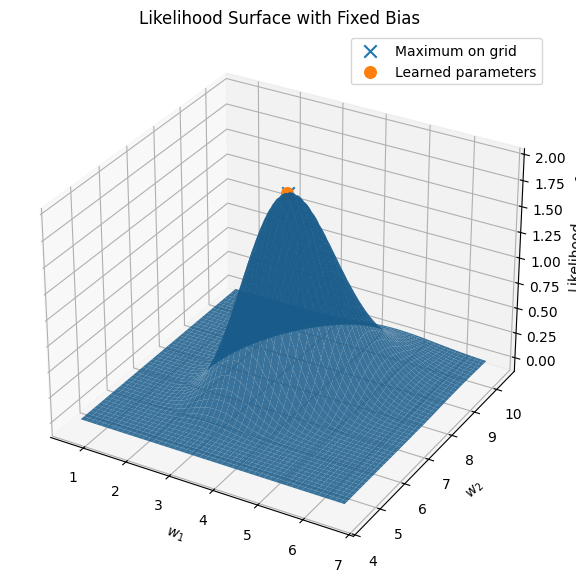

In [24]:
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    w1_grid,
    w2_grid,
    likelihood_grid,
    alpha=0.85,
    antialiased=True
)

ax.scatter(
    w1_max,
    w2_max,
    likelihood_max,
    s=80,
    marker="x",
    label="Maximum on grid"
)

ax.scatter(
    w1_learned,
    w2_learned,
    current_likelihood,
    s=70,
    label="Learned parameters"
)

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_zlabel("Likelihood")
ax.set_title("Likelihood Surface with Fixed Bias")
ax.legend()

plt.show()

## Log-Likelihood?


Da das Produkt bei größeren Datensätzen sehr klein wird und Produkte unhandlicher als Summen sind verwendet man den Logarithmus der Likelihood:

$$
\log L(w,b)
$$

Der Logarithmus verwandelt das Produkt in eine Summe:

$$
\log L(w,b)
=
\sum_{i=1}^{n}
\log\left(
p_i^{y_i}(1-p_i)^{1-y_i}
\right)
$$

Mit den Logarithmusregeln ergibt sich:

$$
\log L(w,b)
=
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Da der Logarithmus monoton steigend ist, verändert er die Lage des Maximums nicht.

In [25]:
log_likelihood_flat = np.sum(np.log(likelihood_contributions), axis=0)
log_likelihood_grid = log_likelihood_flat.reshape(w1_grid.shape)

max_idx_log = np.unravel_index(
    np.argmax(log_likelihood_grid),
    log_likelihood_grid.shape
)

w1_max = w1_grid[max_idx_log]
w2_max = w2_grid[max_idx_log]
log_likelihood_max = log_likelihood_grid[max_idx_log]

current_log_likelihood = np.log(likelihood_table["P(Observed Label)"]).sum()

print(f"Current log-likelihood: {current_log_likelihood:.4f}")
print(f"Maximum log-likelihood on grid: {log_likelihood_max:.4f}")
print(f"Maximum at w1 = {w1_max:.4f}, w2 = {w2_max:.4f}")
print(
    f"Learned parameters: w1 = {w1_learned:.4f}, "
    f"w2 = {w2_learned:.4f} with bias {b_learned:.4f}"
)

Current log-likelihood: -13.1668
Maximum log-likelihood on grid: -13.1667
Maximum at w1 = 3.6780, w2 = 7.3945
Learned parameters: w1 = 3.6629, w2 = 7.3795 with bias 2.6924


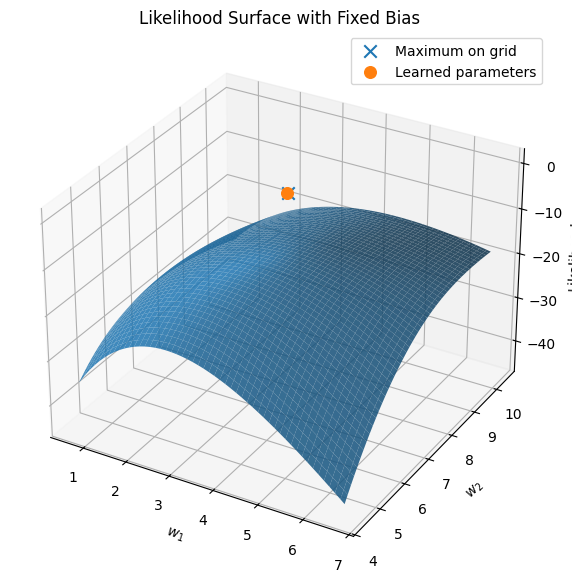

In [26]:
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    w1_grid,
    w2_grid,
    log_likelihood_grid,
    alpha=0.85,
    antialiased=True
)

ax.scatter(
    w1_max,
    w2_max,
    likelihood_max,
    s=80,
    marker="x",
    label="Maximum on grid"
)

ax.scatter(
    w1_learned,
    w2_learned,
    current_likelihood,
    s=70,
    label="Learned parameters"
)

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_zlabel("Likelihood")
ax.set_title("Likelihood Surface with Fixed Bias")
ax.legend()

plt.show()

## Negative Log-Likelihood

Das Maximum-Likelihood-Prinzip ist zunächst ein Maximierungsproblem, aber in Machine Learning und insbesondere im Deep Learning wird Training meist als Minimierung einer Loss-Funktion formuliert. Auch **Backpropagation**, was das Training tiefer Netze überhaupt möglich gemacht hat, berechnet Gradienten einer solchen Zielfunktion, die anschließend von einem Optimierungsverfahren genutzt werden, um die Parameter in Richtung kleinerer Loss-Werte anzupassen.

Mehr dazu folgt später im Kapitel **Backpropagation**.

Deshalb schreiben wir das Maximum-Likelihood-Ziel als äquivalentes Minimierungsproblem um. Dazu drehen wir einfach nur das Vorzeichen der Log-Likelihood um und erhalten die **Negative Log-Likelihood**:

$$
\mathrm{NLL}(w,b) = -\log L(w,b)
$$

Das Maximieren der Log-Likelihood ist damit äquivalent zum Minimieren der Negative Log-Likelihood:

$$
\max_{w,b} \log L(w,b)
\quad
\Longleftrightarrow
\quad
\min_{w,b} \mathrm{NLL}(w,b)
$$

Die Lage des Optimums bleibt gleich. Nur die Perspektive ändert sich: Aus einer Größe, die möglichst groß werden soll, wird eine Loss-Funktion, die möglichst klein werden soll.

In [27]:
negative_log_likelihood_flat = -np.sum(
    np.log(likelihood_contributions),
    axis=0
)

negative_log_likelihood_grid = negative_log_likelihood_flat.reshape(w1_grid.shape)

min_idx_nll = np.unravel_index(
    np.argmin(negative_log_likelihood_grid),
    negative_log_likelihood_grid.shape
)

w1_min = w1_grid[min_idx_nll]
w2_min = w2_grid[min_idx_nll]
negative_log_likelihood_min = negative_log_likelihood_grid[min_idx_nll]

current_negative_log_likelihood = -np.log(
    likelihood_table["P(Observed Label)"]
).sum()

print(f"Current negative log-likelihood: {current_negative_log_likelihood:.4f}")
print(f"Minimum negative log-likelihood on grid: {negative_log_likelihood_min:.4f}")
print(f"Minimum at w1 = {w1_min:.4f}, w2 = {w2_min:.4f}")
print(
    f"Learned parameters: w1 = {w1_learned:.4f}, "
    f"w2 = {w2_learned:.4f} with bias {b_learned:.4f}"
)

Current negative log-likelihood: 13.1668
Minimum negative log-likelihood on grid: 13.1667
Minimum at w1 = 3.6780, w2 = 7.3945
Learned parameters: w1 = 3.6629, w2 = 7.3795 with bias 2.6924


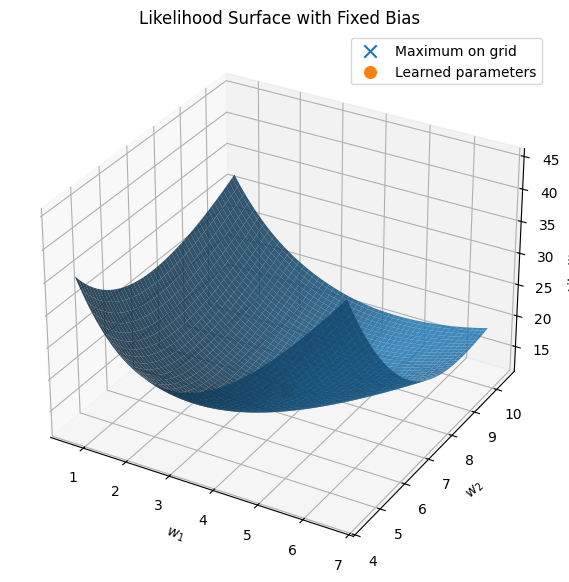

In [28]:
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    w1_grid,
    w2_grid,
    negative_log_likelihood_grid,
    alpha=0.85,
    antialiased=True
)

ax.scatter(
    w1_max,
    w2_max,
    negative_log_likelihood_min,
    s=80,
    marker="x",
    label="Maximum on grid"
)

ax.scatter(
    w1_learned,
    w2_learned,
    current_negative_log_likelihood,
    s=70,
    label="Learned parameters"
)

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_zlabel("Likelihood")
ax.set_title("Likelihood Surface with Fixed Bias")
ax.legend()

plt.show()

Die Negative Log-Likelihood kann entweder als Summe wie hier über alle Datenpunkte oder als Mittelwert angegeben werden. Für die Optimierung spielt der Faktor $\frac{1}{n}$ keine Rolle für die Lage des Optimums, weil er alle Werte nur gleichmäßig skaliert. Für die Vergleichbarkeit zwischen Datensätzen und Trainingsläufen verwendet man jedoch häufig den Mittelwert.

## Verbindung zwischen Negative Log-Likelihood und Binary Cross-Entropy

Die Negative Log-Likelihood für das Bernoulli-Modell lautet:

$$
\mathrm{NLL}(w,b)
=
-
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Wenn wir diesen Ausdruck durch die Anzahl der Datenpunkte $n$ teilen, erhalten wir die mittlere Negative Log-Likelihood:

$$
\frac{1}{n}\mathrm{NLL}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Dieser Ausdruck ist genau die Binary Cross-Entropy über den gesamten Datensatz:

$$
\mathrm{BCE}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Damit gilt:

$$
\mathrm{BCE}(w,b)
=
\frac{1}{n}\mathrm{NLL}(w,b)
$$

Das Minimieren der Binary Cross-Entropy entspricht also dem Minimieren der mittleren Negative Log-Likelihood und damit dem Maximieren der Bernoulli-Likelihood der beobachteten Labels.

Die Binary Cross-Entropy ist also nicht nur eine praktische Loss-Funktion. Unter der Bernoulli-Annahme ist sie genau die mittlere Negative Log-Likelihood der beobachteten Labels. Dadurch erhält das Training des logistischen Perzeptrons eine statistische Interpretation: Die Parameter werden so angepasst, dass die beobachteten Labels unter dem Modell möglichst plausibel werden.

## Zusammenfassung: Was leistet das logistische Perzeptron?

Das logistische Perzeptron erweitert das klassische Perzeptron um eine probabilistische Interpretation. Der lineare Score

$$
z_i = w^\top x_i+b
$$

wird durch die Sigmoid-Funktion in eine Wahrscheinlichkeit transformiert:

$$
p_i = \sigma(z_i)
$$

Unter der Bernoulli-Annahme interpretieren wir diesen Wert als

$$
p_i = P(Y=1 \mid X=x_i,w,b).
$$

Die Binary Cross-Entropy bewertet anschließend, wie viel Wahrscheinlichkeit das Modell den tatsächlich beobachteten Labels zuweist. Aus statistischer Sicht entspricht die mittlere BCE der mittleren Negative Log-Likelihood eines Bernoulli-Modells.

Damit können wir das Training auf zwei äquivalente Arten verstehen:

- Aus Optimierungssicht minimieren wir die Binary Cross-Entropy.
- Aus statistischer Sicht maximieren wir die Likelihood der beobachteten Labels.

Beide Perspektiven führen zur gleichen Trainingsidee.

Die Binary Cross-Entropy besitzt damit zwei wichtige Interpretationen. Aus statistischer Sicht ist sie die mittlere Negative Log-Likelihood eines Bernoulli-Modells. Aus informationstheoretischer Sicht ist sie ein Spezialfall der Cross-Entropy zwischen einer Zielverteilung und einer vorhergesagten Modellverteilung.

In diesem Notebook verwenden wir vor allem die statistische Perspektive, weil sie direkt zur Likelihood und zum Training des logistischen Perzeptrons führt. Die informationstheoretische Bedeutung der Cross-Entropy wird später in einem eigenen Kapitel behandelt.